# 🧠 01 · 스파이킹 뉴런과 스파이크 인코딩

이 시리즈는 스파이킹 신경망(SNN)을 밑바닥부터 하나씩 직접 만들어 보며 배웁니다. 첫 편에서는 SNN의 기본 단위인 **스파이킹 뉴런**을 손으로 구현하고, 이미지·센서값 같은 실수 데이터를 뉴런이 받을 수 있는 **스파이크로 바꾸는 방법(인코딩)** 을 다룹니다.

일반 신경망과 다른 점부터 짚고 갑니다.

- **이벤트 기반(event-driven)**: 뉴런은 연속값 대신 스파이크(0/1 이벤트)를 드문드문 출력합니다. 대부분의 시간엔 침묵하므로 계산이 희소(sparse)하고 에너지 소모가 적습니다.
- **시간 축**: 정보가 발화 타이밍에 실려, 시간에 걸친 이벤트 스트림 형태로 다뤄집니다.
- **뉴로모픽 하드웨어**: Loihi, SpiNNaker 같은 칩이 이 방식을 그대로 구현해 mW급 전력으로 동작합니다.

## 이번 편에서 배우는 것
1. **LIF 뉴런**을 갱신식 그대로 손으로 구현하고, 막전위·누수·리셋·임계값이 무엇인지 이해한다.
2. 입력 전류와 발화율의 관계(**f–I 곡선**)를 확인한다.
3. 실수 데이터를 스파이크로 바꾸는 세 가지 인코딩: **rate, latency, delta**.
4. 스파이크에서 정보를 되읽는 **디코딩**(스파이크 수, 첫 스파이크 시각).

## 0. 개발 환경

터미널에서 가상환경을 만들고 필요한 패키지를 설치합니다.

```bash
python -m venv .venv
source .venv/bin/activate         # Windows: .venv\Scripts\activate
pip install torch snntorch numpy matplotlib jupyterlab
```

- `torch`: 텐서 연산 라이브러리.
- `snntorch`: PyTorch 위에서 스파이킹 뉴런 계층(`snn.Leaky` 등)과 인코딩 유틸(`spikegen`)을 제공.
- `numpy`, `matplotlib`: 수치 계산과 그림.

아래 셀은 이 라이브러리들을 불러오고, 재현성(시드)과 그림 설정을 맞추는 **환경 구성 코드**입니다.

In [1]:
# --- 환경 구성: 라이브러리 불러오기 & 기본 설정 ---
import torch
import snntorch as snn
from snntorch import spikegen
import numpy as np
import matplotlib.pyplot as plt

# 같은 결과가 재현되도록 난수 시드를 고정
torch.manual_seed(42)
np.random.seed(42)

# 한글 폰트 (macOS). 라벨이 네모로 깨지면 'AppleSDGothicNeo' 로 바꿔보세요.
plt.rcParams["font.family"] = "AppleGothic"
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.figsize"] = (9, 3.2)
plt.rcParams["axes.grid"] = True

# 이 노트북 모델은 작아서 CPU로 충분합니다.
device = torch.device("cpu")
print("torch:", torch.__version__, "| snntorch:", snn.__version__, "| device:", device)

torch: 2.12.1 | snntorch: 1.0.0 | device: cpu


## 1. LIF 뉴런: 밑바닥부터

가장 먼저 뉴런 하나를 직접 만들어 봅니다. 생물학적 뉴런은 들어오는 전류를 내부 전압에 모으다가, 그 전압이 일정 수준에 이르면 짧은 전기 펄스(스파이크)를 내보내고 전압이 다시 내려갑니다. **LIF(Leaky Integrate-and-Fire)** 뉴런은 이 동작을 이름 그대로 세 조각으로 모형화합니다.

- **Integrate(적분)**: 입력 전류를 내부 전압에 계속 더해 쌓는다.
- **Leaky(누수)**: 입력이 없으면 쌓인 전압이 시간이 지나며 조금씩 새어 줄어든다.
- **Fire(발화)**: 전압이 임계값에 도달하면 스파이크를 하나 내보내고 전압을 낮춘다(리셋).

여기서 쓰는 용어와 기호:
- **막전위(membrane potential) $V[t]$**: 시각 $t$에 뉴런 내부에 쌓여 있는 전압. 뉴런의 현재 상태를 나타내며, 입력이 들어오면 오르고 가만두면 샙니다.
- **임계값(threshold) $\theta$**: 발화를 일으키는 기준 전압.
- **누수 계수 $\beta$ (0~1)**: 매 스텝 막전위에 곱해지는 값. 1에 가까울수록 천천히 새서 과거를 오래 기억하고, 작을수록 빨리 샙니다.
- **입력 전류 $I[t]$**, **스파이크 $S[t]$**: 시각 $t$의 입력과, 그 순간 발화했는지(1 또는 0).

이 동작을 이산 시간 갱신식 세 줄로 쓰면 위 세 조각과 그대로 대응됩니다.

$$ V[t] = \beta\,V[t-1] + I[t] \qquad \text{(Leaky + Integrate)} $$
$$ S[t] = \begin{cases} 1 & V[t] \ge \theta \\ 0 & \text{그 외} \end{cases} \qquad \text{(Fire)} $$
$$ V[t] \leftarrow V[t] - S[t]\cdot\theta \qquad \text{(Reset)} $$

- 첫 줄: 직전 막전위에서 누수되고 남은 $\beta V[t-1]$에 이번 입력 $I[t]$를 더합니다.
- 둘째 줄은 **발화의 정의**입니다. 막전위가 임계값에 도달하는 순간을 "스파이크가 났다"고 보기 때문에, $V[t] \ge \theta$이면 $S[t]=1$입니다.
- 셋째 줄은 **리셋**입니다. 발화한 뒤 막전위를 낮춥니다. 이 과정이 없으면 막전위가 임계값 위에 계속 머물러 매 스텝 발화하게 됩니다. 낮추는 방법은 두 가지가 흔히 쓰입니다.
  - `subtract`: $V \leftarrow V-\theta$ — 임계값만큼만 빼서 초과분 $V-\theta$ 를 남깁니다.
  - `zero`: $V \leftarrow 0$ — 0으로 되돌려 초과분을 버립니다.

아래 코드는 기성 계층을 쓰지 않고 위 세 줄을 그대로 파이썬 루프로 구현해, 두 리셋 방식을 같은 입력에 대해 비교합니다.

In [2]:
beta, threshold = 0.9, 1.0
T = 150

# 계단식으로 세지는 입력 전류
cur = torch.zeros(T)
cur[20:70]  = 0.20
cur[80:140] = 0.45

def run_lif(reset):
    # 위 갱신식 세 줄을 그대로 구현
    V = 0.0
    V_rec, S_rec = [], []
    for t in range(T):
        V = beta * V + cur[t].item()              # (1) Leaky + Integrate
        S = 1.0 if V >= threshold else 0.0        # (2) Fire
        V_rec.append(V); S_rec.append(S)          # 리셋 전 막전위를 기록(임계 도달이 보이게)
        if S > 0:                                 # (3) Reset (다음 스텝을 위해)
            V = V - threshold if reset == "subtract" else 0.0
    return np.array(V_rec), np.array(S_rec)

mem_sub,  spk_sub  = run_lif("subtract")
mem_zero, spk_zero = run_lif("zero")
print("subtract 스파이크:", int(spk_sub.sum()), "| zero 스파이크:", int(spk_zero.sum()))

subtract 스파이크: 31 | zero 스파이크: 27


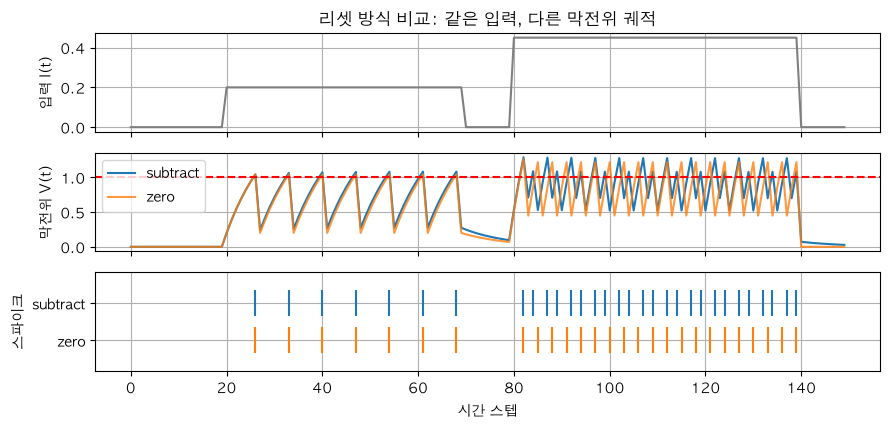

In [3]:
fig, ax = plt.subplots(3, 1, figsize=(9, 4.4), sharex=True)
ax[0].plot(cur.numpy(), color="tab:gray"); ax[0].set_ylabel("입력 I(t)")
ax[0].set_title("리셋 방식 비교: 같은 입력, 다른 막전위 궤적")

ax[1].plot(mem_sub, color="tab:blue", label="subtract")
ax[1].plot(mem_zero, color="tab:orange", label="zero", alpha=0.8)
ax[1].axhline(threshold, ls="--", c="r"); ax[1].set_ylabel("막전위 V(t)"); ax[1].legend(loc="upper left")

ax[2].eventplot(np.where(spk_sub>0)[0], colors="tab:blue", lineoffsets=1, linelengths=0.7)
ax[2].eventplot(np.where(spk_zero>0)[0], colors="tab:orange", lineoffsets=0, linelengths=0.7)
ax[2].set_yticks([0,1]); ax[2].set_yticklabels(["zero","subtract"])
ax[2].set_ylabel("스파이크"); ax[2].set_xlabel("시간 스텝")
plt.tight_layout(); plt.show()

### 🔎 조금 더 들어가기: 리셋 방식이 만드는 차이
강한 입력 구간(80~140)에서 `subtract`가 `zero`보다 더 촘촘하게 발화합니다. `subtract`는 임계값을 넘긴 초과분을 다음 스텝으로 넘겨주므로 다음 발화까지 걸리는 시간이 짧아지기 때문입니다. `zero`는 매번 0으로 되돌려 그 초과분을 버리므로 발화 간격이 조금 더 벌어집니다.

즉 같은 뉴런이라도 리셋 규칙 하나로 스파이크가 찍히는 시점이 달라집니다. SNN에서 "언제 발화하는가"는 이런 작은 규칙들이 결정합니다.

## 2. f–I 곡선: 입력 전류와 발화율

앞의 갱신식을 매번 직접 반복하는 대신, 지금부터는 같은 LIF 뉴런을 snntorch의 `snn.Leaky`로 간단히 씁니다.

LIF 뉴런은 입력 전류를 발화율(firing rate, 단위 시간당 스파이크 수)로 바꾸는 비선형 함수입니다. 신경망의 ReLU/GELU가 입력을 출력으로 바꾸는 것과 같은 역할을 하며, 그 출력이 시간에 걸친 발화율로 나타납니다. 일정한 입력 전류 $I$를 계속 넣고 스파이크 수를 세면 **f–I 곡선**을 얻습니다.

- 입력이 임계값을 넘길 만큼 크지 않으면 막전위가 임계값에 못 미쳐 발화율은 0입니다.
- 임계값을 넘으면 입력이 셀수록 더 자주 발화해 발화율이 대체로 단조 증가합니다.

이 관계가 SNN이 신호의 세기를 표현하는 기본 방식(rate coding)의 바탕입니다.

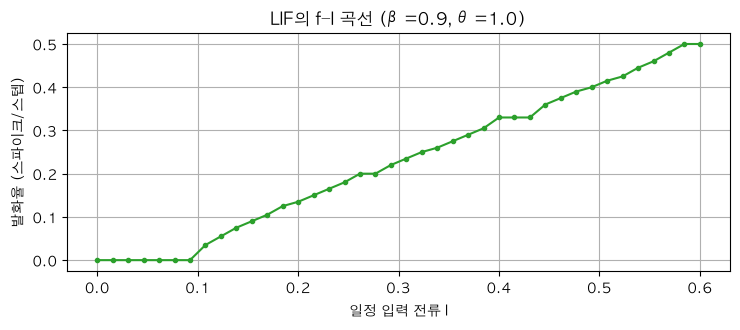

발화 시작 지점(임계 전류) 근처: I ≈ 0.108


In [4]:
beta, threshold, T = 0.9, 1.0, 200
currents = torch.linspace(0.0, 0.6, 40)
rates = []
for I in currents:
    lif = snn.Leaky(beta=beta, threshold=threshold, reset_mechanism="subtract")
    mem = torch.zeros(1); n = 0
    for t in range(T):
        spk, mem = lif(I.reshape(1), mem)     # snn.Leaky: (전류, 막전위) -> (스파이크, 새 막전위)
        n += int(spk.item())
    rates.append(n / T)                        # 스텝당 발화율

fig, ax = plt.subplots(figsize=(7.5, 3.4))
ax.plot(currents.numpy(), rates, marker="o", ms=3, color="tab:green")
ax.set_xlabel("일정 입력 전류 I"); ax.set_ylabel("발화율 (스파이크/스텝)")
ax.set_title(f"LIF의 f–I 곡선 (β={beta}, θ={threshold})")
plt.tight_layout(); plt.show()
print(f"발화 시작 지점(임계 전류) 근처: I ≈ {currents[np.argmax(np.array(rates)>0)]:.3f}")

## 3. 스파이크 인코딩: 실수 데이터 → 스파이크

앞에서 만든 뉴런은 전류(또는 스파이크)를 입력으로 받습니다. 이미지·센서값 같은 실수 데이터를 SNN에 넣으려면 먼저 스파이크 열로 바꿔야 합니다. 값을 스파이크의 어느 성질에 싣느냐에 따라 세 가지 방식이 있습니다.

| 방식 | 정보를 싣는 곳 | 직관 | snntorch |
|---|---|---|---|
| **Rate** | 스파이크 **개수/빈도** | 값이 클수록 자주 발화 | `spikegen.rate` |
| **Latency** | 첫 스파이크 **타이밍** | 값이 클수록 빨리 발화 | `spikegen.latency` |
| **Delta** | 값의 **변화** | 신호가 확 바뀔 때만 발화 (이벤트 카메라) | `spikegen.delta` |

먼저 인코딩할 합성 이미지(중앙이 밝은 가우시안 blob) 하나를 만듭니다.

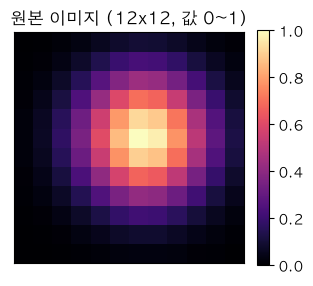

In [5]:
# 12x12 합성 이미지: 중앙이 밝은 가우시안 blob (값 0~1)
g = 12
yy, xx = np.meshgrid(np.linspace(-1,1,g), np.linspace(-1,1,g), indexing="ij")
img = np.exp(-((xx-0.15)**2 + (yy+0.1)**2) / 0.35).astype(np.float32)
img = (img - img.min())/(img.max()-img.min())
img_t = torch.tensor(img).flatten()   # 144차원 벡터

fig, ax = plt.subplots(figsize=(3.2,3.2))
im = ax.imshow(img, cmap="magma"); ax.set_title("원본 이미지 (12x12, 값 0~1)")
ax.set_xticks([]); ax.set_yticks([]); plt.colorbar(im, fraction=0.046); plt.tight_layout(); plt.show()

### 3-1. Rate coding — 값을 발화 확률로

각 스텝마다 베르누이 시행(확률 $p$로 1, 아니면 0)을 하고, 그 확률 $p$를 픽셀 값으로 둡니다. 값이 큰 픽셀일수록 스파이크가 잦아집니다. 반대로 스파이크를 시간축으로 평균하면 각 픽셀의 발화 빈도가 원래 값에 가까워지므로, 원본이 (잡음이 섞인 채로) 복원됩니다.

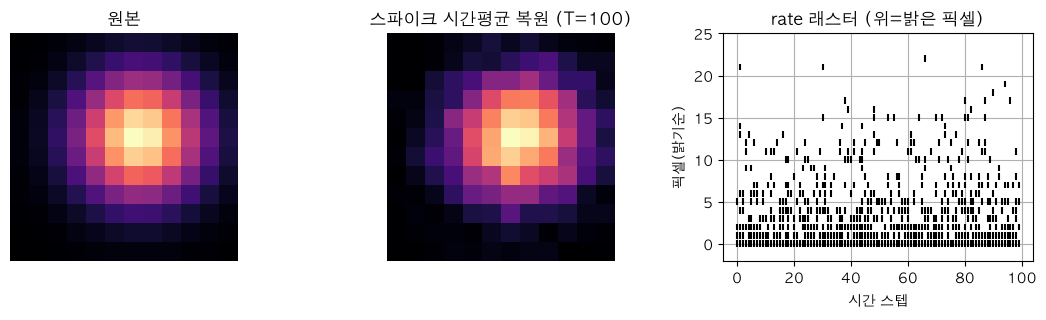

In [6]:
T = 100
rate_spk = spikegen.rate(img_t, num_steps=T)        # [T, 144]
recon = rate_spk.float().mean(0).reshape(g, g)      # 시간평균 = 복원

fig, ax = plt.subplots(1, 3, figsize=(11, 3.3))
ax[0].imshow(img, cmap="magma"); ax[0].set_title("원본"); ax[0].axis("off")
ax[1].imshow(recon.numpy(), cmap="magma"); ax[1].set_title(f"스파이크 시간평균 복원 (T={T})"); ax[1].axis("off")

# 대표 픽셀 24개의 래스터 (밝은 픽셀일수록 촘촘)
idx = torch.argsort(img_t, descending=True)[torch.linspace(0,143,24).long()]
rows = [np.where(rate_spk[:, i].numpy()>0)[0] for i in idx]
ax[2].eventplot(rows, colors="k", linelengths=0.8)
ax[2].set_title("rate 래스터 (위=밝은 픽셀)"); ax[2].set_xlabel("시간 스텝"); ax[2].set_ylabel("픽셀(밝기순)")
plt.tight_layout(); plt.show()

### 3-2. Latency coding — 값을 첫 스파이크 시각으로

값이 클수록 일찍, 작을수록 늦게 (픽셀당 한 번) 발화합니다. 정보가 개수가 아니라 타이밍에 실리므로 스파이크가 훨씬 희소합니다(픽셀당 최대 1개). 픽셀별 첫 스파이크 시각을 이미지로 그리면, 밝은 곳이 먼저 켜지는 것이 보입니다.

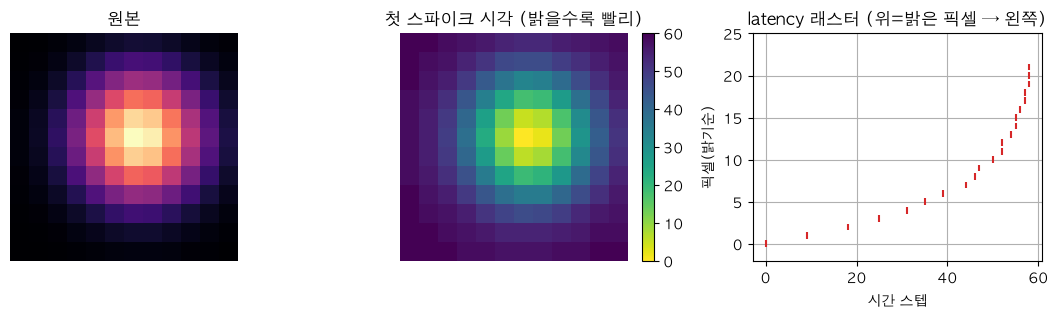

총 스파이크 수 —  rate: 1955  latency: 131 (latency가 훨씬 희소)


In [7]:
T = 60
lat_spk = spikegen.latency(img_t, num_steps=T, tau=5, threshold=0.01,
                           clip=True, normalize=True, linear=True)  # [T,144]

# 픽셀별 첫 스파이크 시각
first = np.full(img_t.numel(), T, dtype=float)
ts, us = torch.where(lat_spk > 0)
for t, u in zip(ts.tolist(), us.tolist()):
    if t < first[u]:
        first[u] = t
first_img = first.reshape(g, g)

fig, ax = plt.subplots(1, 3, figsize=(11, 3.3))
ax[0].imshow(img, cmap="magma"); ax[0].set_title("원본"); ax[0].axis("off")
im = ax[1].imshow(first_img, cmap="viridis_r")
ax[1].set_title("첫 스파이크 시각 (밝을수록 빨리)"); ax[1].axis("off"); plt.colorbar(im, ax=ax[1], fraction=0.046)
idx = torch.argsort(img_t, descending=True)[torch.linspace(0,143,24).long()]
rows = [np.where(lat_spk[:, i].numpy()>0)[0] for i in idx]
ax[2].eventplot(rows, colors="tab:red", linelengths=0.8)
ax[2].set_title("latency 래스터 (위=밝은 픽셀 → 왼쪽)"); ax[2].set_xlabel("시간 스텝"); ax[2].set_ylabel("픽셀(밝기순)")
plt.tight_layout(); plt.show()
print("총 스파이크 수 —  rate:", int(spikegen.rate(img_t,num_steps=60).sum()), " latency:", int(lat_spk.sum()), "(latency가 훨씬 희소)")

### 3-3. Delta coding — 값의 변화에만 발화

rate와 latency는 정지된 값 하나를 인코딩합니다. delta는 시간에 따라 변하는 신호를 받아, 직전 값보다 임계 이상 커지면 양(+) 스파이크, 작아지면 음(−) 스파이크를 냅니다. 이벤트 카메라(DVS)가 픽셀 밝기 변화를 이런 방식으로 스트리밍합니다. 변화가 없는 구간에서는 침묵하므로 매우 희소합니다.

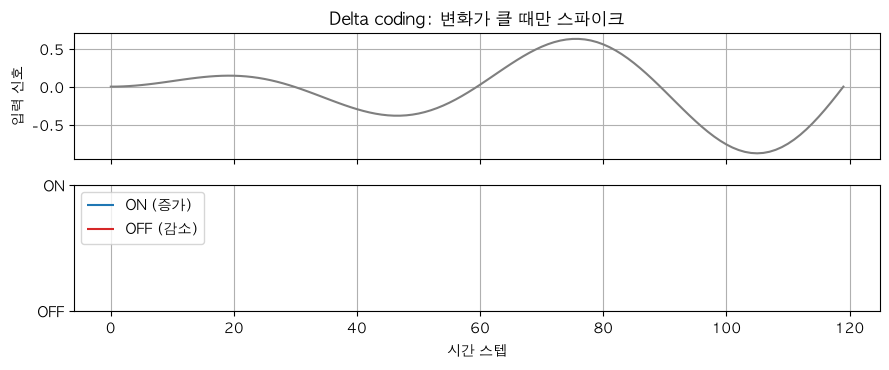

In [8]:
T = 120
t_axis = torch.linspace(0, 4*np.pi, T)
signal = (torch.sin(t_axis) * (t_axis/ (4*np.pi))).unsqueeze(1)   # 진폭이 커지는 사인파 [T,1]
delta_spk = spikegen.delta(signal, threshold=0.15, off_spike=True) # +1 / -1 스파이크

fig, ax = plt.subplots(2, 1, figsize=(9, 3.8), sharex=True)
ax[0].plot(signal[:,0].numpy(), color="tab:gray"); ax[0].set_ylabel("입력 신호"); ax[0].set_title("Delta coding: 변화가 클 때만 스파이크")
up = np.where(delta_spk[:,0].numpy() > 0)[0]; dn = np.where(delta_spk[:,0].numpy() < 0)[0]
ax[1].eventplot(up, colors="tab:blue", lineoffsets=1, linelengths=0.7, label="ON (증가)")
ax[1].eventplot(dn, colors="tab:red", lineoffsets=0, linelengths=0.7, label="OFF (감소)")
ax[1].set_yticks([0,1]); ax[1].set_yticklabels(["OFF","ON"]); ax[1].set_xlabel("시간 스텝"); ax[1].legend(loc="upper left")
plt.tight_layout(); plt.show()

## 4. 디코딩: 스파이크에서 정보 되읽기

인코딩이 값을 스파이크로 바꾸는 과정이었다면, 디코딩은 그 반대로 스파이크에서 다시 값을 읽어내는 과정입니다. 뒤 편들에서 뉴런의 출력을 판단하거나 학습에 쓰려면 이 과정이 필요합니다. 인코딩과 짝을 이루는 두 가지 대표 방법이 있습니다.

- **스파이크 수(rate readout)**: 시간창 동안 스파이크를 셉니다. rate coding과 짝을 이룹니다.
- **첫 스파이크 시각(latency readout)**: 어느 뉴런이 먼저 발화했는지를 봅니다. latency coding과 짝을 이루며, 몇 스텝 만에 판단할 수 있어 추론이 빠릅니다.

아래는 세 클래스 뉴런이 서로 다른 발화율을 가질 때, 두 디코딩이 같은 정답(가장 활발한 뉴런)을 가리키는지 확인합니다.

스파이크 수 : [11.0, 18.0, 55.0] -> 예측(argmax): 2
첫 스파이크 : [12, 5, 0] -> 예측(argmin): 2
정답 클래스 : 2


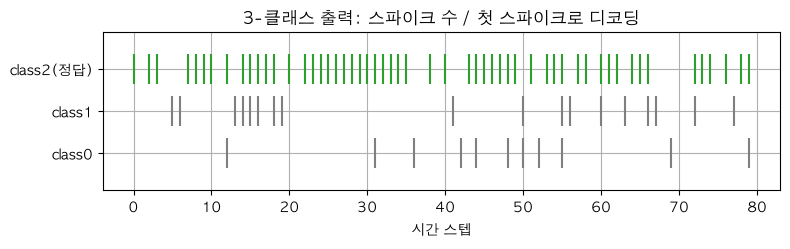

In [9]:
T = 80
true_class = 2
rates3 = torch.tensor([0.1, 0.25, 0.6])          # 클래스별 발화 확률 (2번이 최다)
out_spk = spikegen.rate(rates3, num_steps=T)     # [T,3]

count = out_spk.sum(0)                            # 스파이크 수
first_t = torch.tensor([ (torch.where(out_spk[:,c]>0)[0][:1].item()
                          if out_spk[:,c].sum()>0 else T) for c in range(3)])
print("스파이크 수 :", count.tolist(), "-> 예측(argmax):", int(count.argmax()))
print("첫 스파이크 :", first_t.tolist(), "-> 예측(argmin):", int(first_t.argmin()))
print("정답 클래스 :", true_class)

fig, ax = plt.subplots(figsize=(8,2.6))
rows = [np.where(out_spk[:,c].numpy()>0)[0] for c in range(3)]
ax.eventplot(rows, colors=["tab:gray","tab:gray","tab:green"], linelengths=0.7)
ax.set_yticks([0,1,2]); ax.set_yticklabels(["class0","class1","class2(정답)"])
ax.set_xlabel("시간 스텝"); ax.set_title("3-클래스 출력: 스파이크 수 / 첫 스파이크로 디코딩")
plt.tight_layout(); plt.show()

## 5. 정리 & 다음 단계

### 배운 것
- **LIF 뉴런**: 입력을 막전위에 쌓고(Integrate), 시간에 따라 새고(Leaky), 임계값에서 발화 후 리셋(Fire)한다. 갱신식 세 줄로 직접 구현했다.
- 리셋 방식(subtract, zero)이 발화 시점을 바꾼다.
- **f–I 곡선**: 뉴런은 입력 전류를 발화율로 바꾸는 비선형이다.
- **인코딩 3종**: rate(개수), latency(타이밍, 희소), delta(변화, 초희소). **디코딩**: 스파이크 수, 첫 스파이크 시각.

### 직접 바꿔보면 좋은 것
- 1절 `run_lif`의 `beta`를 `0.5`로 낮춰 보기 → 막전위가 빨리 새서 발화가 줄어드는지.
- latency 셀의 `tau`를 `1`, `10`으로 → 첫 스파이크 시각 분포가 어떻게 퍼지는지.
- delta 셀의 `threshold`를 `0.05`와 `0.4`로 → 스파이크가 얼마나 촘촘/희소해지는지.

### 다음으로 (`02`)
이제 데이터를 스파이크로 바꿀 수 있으니, 다음 편에서는 정답 라벨 없이 시냅스가 스스로 패턴을 학습하는 첫 규칙 **STDP**로 갑니다. "먼저 발화한 입력이 출력의 발화를 도왔다면 그 연결을 강화한다"는 규칙을, 앞에서처럼 직접 구현해 확인합니다.